# BST vs RBBST Benchmark Analysis

This notebook analyzes and compares **BST** and **RBBST** performance using `TreeBench.csv`.

## Experiment setup captured in the CSV
- 4 operations: `Insertion`, `Deletion`, `Contains`, `TreeSort`
- 4 input distributions: `RANDOM`, `NEARLY_SORTED_1`, `NEARLY_SORTED_5`, `NEARLY_SORTED_10`
- 2 data structures: `BST`, `RBBST`
- 20 runs per combination
- Runtime metrics: `min`, `max`, `mean`, `median` (milliseconds)
- Structural metric: `height`

## What this notebook provides
- Data loading + validation
- Aggregated comparison tables
- BST vs RBBST speedup analysis
- Visual comparisons for runtime and height
- Operation-wise conclusions

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Optional: prettier charts if seaborn is available.
try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="notebook")
    HAS_SEABORN = True
except Exception:
    HAS_SEABORN = False

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

CSV_PATH = "TreeBench.csv"

OPERATIONS_ORDER = ["Insertion", "Deletion", "Contains", "TreeSort"]
DISTRIBUTIONS_ORDER = ["RANDOM", "NEARLY_SORTED_10", "NEARLY_SORTED_5", "NEARLY_SORTED_1"]
STRUCTURES_ORDER = ["BST", "RBBST"]

def fmt_ms_short(x, pos):
    # Compact formatter to keep y-axis readable after converting to ms.
    if x >= 1e3:
        return f"{x/1e3:.1f}K"
    if x >= 1:
        return f"{x:.1f}"
    return f"{x:.3f}"

In [31]:
df = pd.read_csv(CSV_PATH)

# Remove BOM if present in the first header and trim whitespace from all headers.
df.columns = [c.replace("\ufeff", "").strip() for c in df.columns]

# Normalize key categorical fields.
for col in ["operation", "distribution", "dataStructure"]:
    df[col] = df[col].astype(str).str.strip()

# Ensure numeric metrics are numeric.
numeric_cols = ["runs", "height", "min", "max", "mean", "median", "std", "speedup"]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Convert runtime metrics from nanoseconds to milliseconds for reporting.
runtime_cols = ["min", "max", "mean", "median", "std"]
for col in runtime_cols:
    if col in df.columns:
        df[col] = df[col] / 1_000_000

print(f"Rows: {len(df)}")
print("Columns:", list(df.columns))
print("\nOperations:", sorted(df["operation"].dropna().unique()))
print("Distributions:", sorted(df["distribution"].dropna().unique()))
print("Structures:", sorted(df["dataStructure"].dropna().unique()))

df.head()

Rows: 640
Columns: ['operation', 'distribution', 'dataStructure', 'runs', 'height', 'min', 'max', 'mean', 'median', 'std', 'speedup']

Operations: ['Contains', 'Deletion', 'Insertion', 'TreeSort']
Distributions: ['NEARLY_SORTED_1', 'NEARLY_SORTED_10', 'NEARLY_SORTED_5', 'RANDOM']
Structures: ['BST', 'RBBST']


,operation,distribution,dataStructure,runs,height,min,max,mean,median,std,speedup
0,Insertion,RANDOM,BST,20,46,34.8505,59.2659,39.962625,36.67015,7.298381,1.000000
1,Insertion,RANDOM,RBBST,20,19,40.5076,54.3032,44.645190,44.55955,4.068388,0.895116
2,Contains,RANDOM,BST,20,46,35.1270,122.0597,57.825015,47.23335,21.003749,1.000000
3,Contains,RANDOM,RBBST,20,19,39.4435,64.4789,48.951220,45.95995,7.367833,1.181278
4,Deletion,RANDOM,BST,20,45,7.1381,16.6229,10.478230,10.18235,1.945876,1.000000


## Validate Benchmark Shape

We expect exactly 20 runs for each `(operation, distribution, dataStructure)` combination.

In [32]:
run_counts = (
    df.groupby(["operation", "distribution", "dataStructure"], dropna=False)
      .size()
      .reset_index(name="run_count")
      .sort_values(["operation", "distribution", "dataStructure"])
)

unexpected = run_counts[run_counts["run_count"] != 20]
print(f"Expected combinations: {4 * 4 * 2} | Found: {len(run_counts)}")
print(f"Combinations with run_count != 20: {len(unexpected)}")

if len(unexpected) > 0:
    display(unexpected)
else:
    print("All combinations have exactly 20 runs.")

run_counts.head(8)

Expected combinations: 32 | Found: 32
Combinations with run_count != 20: 0
All combinations have exactly 20 runs.


,operation,distribution,dataStructure,run_count
0,Contains,NEARLY_SORTED_1,BST,20
1,Contains,NEARLY_SORTED_1,RBBST,20
2,Contains,NEARLY_SORTED_10,BST,20
3,Contains,NEARLY_SORTED_10,RBBST,20
4,Contains,NEARLY_SORTED_5,BST,20
5,Contains,NEARLY_SORTED_5,RBBST,20
6,Contains,RANDOM,BST,20
7,Contains,RANDOM,RBBST,20


## Aggregate Statistics Across the 20 Runs

For each `(operation, distribution, dataStructure)`, compute:
- average, median, minimum, maximum of `height`
- average, median, minimum, maximum of each runtime metric (`min`, `max`, `mean`, `median`)

In [45]:
group_cols = ["operation", "distribution", "dataStructure"]
metric_cols = ["height", "min", "max", "mean", "median"]

agg = (
    df.groupby(group_cols, dropna=False)[metric_cols]
      .agg(["mean", "median", "min", "max"])
)

# Flatten MultiIndex columns: (metric, aggfn) -> metric_aggfn
agg.columns = [f"{metric}_{fn}" for metric, fn in agg.columns]
agg = agg.reset_index().sort_values(group_cols)

print(f"Rows in aggregated table: {len(agg)}")

# Build LaTeX manually to avoid optional pandas/jinja2 dependency.
def _latex_escape(value: str) -> str:
    return (
        str(value)
        .replace('\\', r'\\textbackslash{}')
        .replace('&', r'\\&')
        .replace('%', r'\\%')
        .replace('$', r'\\$')
        .replace('#', r'\\#')
        .replace('_', r'\\_')
        .replace('{', r'\\{')
        .replace('}', r'\\}')
        .replace('~', r'\\textasciitilde{}')
        .replace('^', r'\\textasciicircum{}')
    )

# Export only a sample of aggregated rows (instead of the full table).
sample_n = min(12, len(agg))
agg_sample = agg.sample(n=sample_n, random_state=42).sort_values(group_cols).reset_index(drop=True)

headers = agg_sample.columns.tolist()
col_spec = 'l' * len(headers)
lines = []
lines.append(r'\\begin{table}[ht]')
lines.append(r'\\centering')
lines.append(rf'\\caption{{Sample of aggregated results ({sample_n} rows) by operation, distribution, and data structure}}')
lines.append(r'\\label{tab:aggregated_results_sample}')
lines.append(rf'\\begin{{tabular}}{{{col_spec}}}')
lines.append(r'\\hline')
lines.append(' & '.join(_latex_escape(h) for h in headers) + r' \\\\')
lines.append(r'\\hline')

for _, row in agg_sample.iterrows():
    row_vals = []
    for col in headers:
        val = row[col]
        if pd.isna(val):
            row_vals.append('')
        elif isinstance(val, (float, np.floating)):
            row_vals.append(f"{val:.6f}")
        else:
            row_vals.append(_latex_escape(val))
    lines.append(' & '.join(row_vals) + r' \\\\')

lines.append(r'\\hline')
lines.append(r'\\end{tabular}')
lines.append(r'\\end{table}')
latex_agg = '\n'.join(lines)

print(f"\nLaTeX table for aggregated sample ({sample_n} rows):\n")
print(latex_agg)

agg_sample

Rows in aggregated table: 32

LaTeX table for aggregated sample (12 rows):

\\begin{table}[ht]
\\centering
\\caption{Sample of aggregated results (12 rows) by operation, distribution, and data structure}
\\label{tab:aggregated_results_sample}
\\begin{tabular}{lllllllllllllllllllllll}
\\hline
operation & distribution & dataStructure & height\\_mean & height\\_median & height\\_min & height\\_max & min\\_mean & min\\_median & min\\_min & min\\_max & max\\_mean & max\\_median & max\\_min & max\\_max & mean\\_mean & mean\\_median & mean\\_min & mean\\_max & median\\_mean & median\\_median & median\\_min & median\\_max \\\\
\\hline
Contains & NEARLY\\_SORTED\\_1 & BST & 3789.000000 & 4025.000000 & 1862 & 4865 & 139.133770 & 125.492650 & 82.494400 & 242.216800 & 152.909850 & 134.701300 & 86.429700 & 256.403600 & 144.663144 & 129.277877 & 85.483265 & 249.893910 & 144.220403 & 129.578575 & 85.578050 & 250.279400 \\\\
Contains & NEARLY\\_SORTED\\_5 & BST & 1586.400000 & 1528.000000 & 980 & 2403

,operation,distribution,dataStructure,height_mean,height_median,height_min,height_max,min_mean,min_median,min_min,min_max,max_mean,max_median,max_min,max_max,mean_mean,mean_median,mean_min,mean_max,median_mean,median_median,median_min,median_max
0,Contains,NEARLY_SORTED_1,BST,3789.00,4025.0,1862,4865,139.133770,125.49265,82.4944,242.2168,152.909850,134.70130,86.4297,256.4036,144.663144,129.277877,85.483265,249.893910,144.220403,129.578575,85.57805,250.27940
1,Contains,NEARLY_SORTED_5,BST,1586.40,1528.0,980,2403,33.443530,30.97815,24.0233,54.2374,35.716465,33.44630,24.5556,56.5456,34.732844,32.193690,24.280460,54.706510,34.768725,32.029900,24.25910,54.77290
2,Deletion,NEARLY_SORTED_1,BST,3003.00,3197.5,1460,3855,39.504140,37.52840,27.3847,58.3594,44.365160,42.18185,30.2188,63.8185,41.422150,38.651228,29.549940,60.860500,41.226035,38.664500,29.76060,60.85250
3,Deletion,NEARLY_SORTED_1,RBBST,19.40,19.0,19,20,9.108755,8.71785,8.0510,13.0622,11.974655,10.56645,10.0179,25.1015,10.470048,9.888395,9.752400,18.462725,10.457593,9.906625,9.83175,18.69585
4,Deletion,NEARLY_SORTED_5,BST,1262.25,1225.0,784,1907,13.613485,13.16900,11.5160,18.2473,16.298505,15.10850,13.1694,32.5167,14.880835,14.208670,12.644465,23.778025,14.709450,14.121100,12.62405,22.26135
5,Deletion,RANDOM,RBBST,19.05,19.0,19,20,9.368905,9.55815,7.8627,10.6501,12.568425,12.15665,11.5665,16.8199,11.317904,11.302645,11.069275,11.589090,11.354228,11.390075,11.10480,11.53285
6,Insertion,NEARLY_SORTED_1,BST,3789.00,4025.0,1862,4865,151.861085,137.59720,91.3088,265.0627,167.899770,151.80575,107.8735,296.7833,155.407597,141.329217,92.837245,269.071420,154.105120,139.601850,92.06480,266.44175
7,Insertion,NEARLY_SORTED_1,RBBST,29.00,29.0,29,29,15.932190,15.82895,15.6737,16.5579,23.701365,23.42900,17.2551,31.1676,16.922421,16.737268,16.162275,18.802490,16.477400,16.185900,15.98455,18.07485
8,TreeSort,NEARLY_SORTED_1,BST,3789.00,4025.0,1862,4865,153.865930,140.92465,95.6062,264.6980,174.748350,163.16940,112.2930,293.8699,158.437085,144.458295,97.341910,275.999230,157.137272,144.131425,96.53035,273.60390
9,TreeSort,NEARLY_SORTED_1,RBBST,29.00,29.0,29,29,19.134210,19.05695,18.7706,19.8716,32.611660,33.73525,23.8563,41.0208,20.631373,20.639735,19.880855,21.482695,19.786130,19.824025,19.11200,20.24160


## Direct BST vs RBBST Comparison

This comparison uses the aggregated `mean_mean` runtime (mean of the per-run `mean` values):
- `speedup_bst_over_rbbst = BST_time / RBBST_time`
- If speedup > 1, **RBBST is faster**
- If speedup < 1, **BST is faster**

In [47]:
cmp = (
    agg.pivot_table(
        index=["operation", "distribution"],
        columns="dataStructure",
        values=["mean_mean", "height_mean", "median_median"],
        aggfunc="first"
    )
)

cmp.columns = [f"{metric}_{ds}" for metric, ds in cmp.columns]
cmp = cmp.reset_index()

cmp["speedup_bst_over_rbbst"] = cmp["mean_mean_BST"] / cmp["mean_mean_RBBST"]
cmp["height_ratio_bst_over_rbbst"] = cmp["height_mean_BST"] / cmp["height_mean_RBBST"]
cmp["winner"] = np.where(cmp["speedup_bst_over_rbbst"] > 1, "RBBST", "BST")

cmp.sort_values(["operation", "distribution"])

,operation,distribution,height_mean_BST,height_mean_RBBST,mean_mean_BST,mean_mean_RBBST,median_median_BST,median_median_RBBST,speedup_bst_over_rbbst,height_ratio_bst_over_rbbst,winner
0,Contains,NEARLY_SORTED_1,3789.00,29.00,144.663144,9.639771,129.578575,9.697150,15.006906,130.655172,RBBST
1,Contains,NEARLY_SORTED_10,1097.65,28.00,27.958684,15.352479,27.530200,14.828450,1.821119,39.201786,RBBST
2,Contains,NEARLY_SORTED_5,1586.40,29.00,34.732844,11.864921,32.029900,11.808275,2.927356,54.703448,RBBST
3,Contains,RANDOM,39.35,19.25,43.755485,40.594065,43.505250,40.629125,1.077879,2.044156,RBBST
4,Deletion,NEARLY_SORTED_1,3003.00,19.40,41.422150,10.470048,38.664500,9.906625,3.956252,154.793814,RBBST
5,Deletion,NEARLY_SORTED_10,882.00,20.45,12.555409,11.566272,11.974650,10.976725,1.085519,43.129584,RBBST
6,Deletion,NEARLY_SORTED_5,1262.25,20.20,14.880835,10.438420,14.121100,10.425475,1.425583,62.487624,RBBST
7,Deletion,RANDOM,38.70,19.05,10.126217,11.317904,10.025000,11.390075,0.894708,2.031496,BST
8,Insertion,NEARLY_SORTED_1,3789.00,29.00,155.407597,16.922421,139.601850,16.185900,9.183532,130.655172,RBBST
9,Insertion,NEARLY_SORTED_10,1097.65,28.00,28.062889,23.336677,27.613525,22.722300,1.202523,39.201786,RBBST


## Visual Analysis

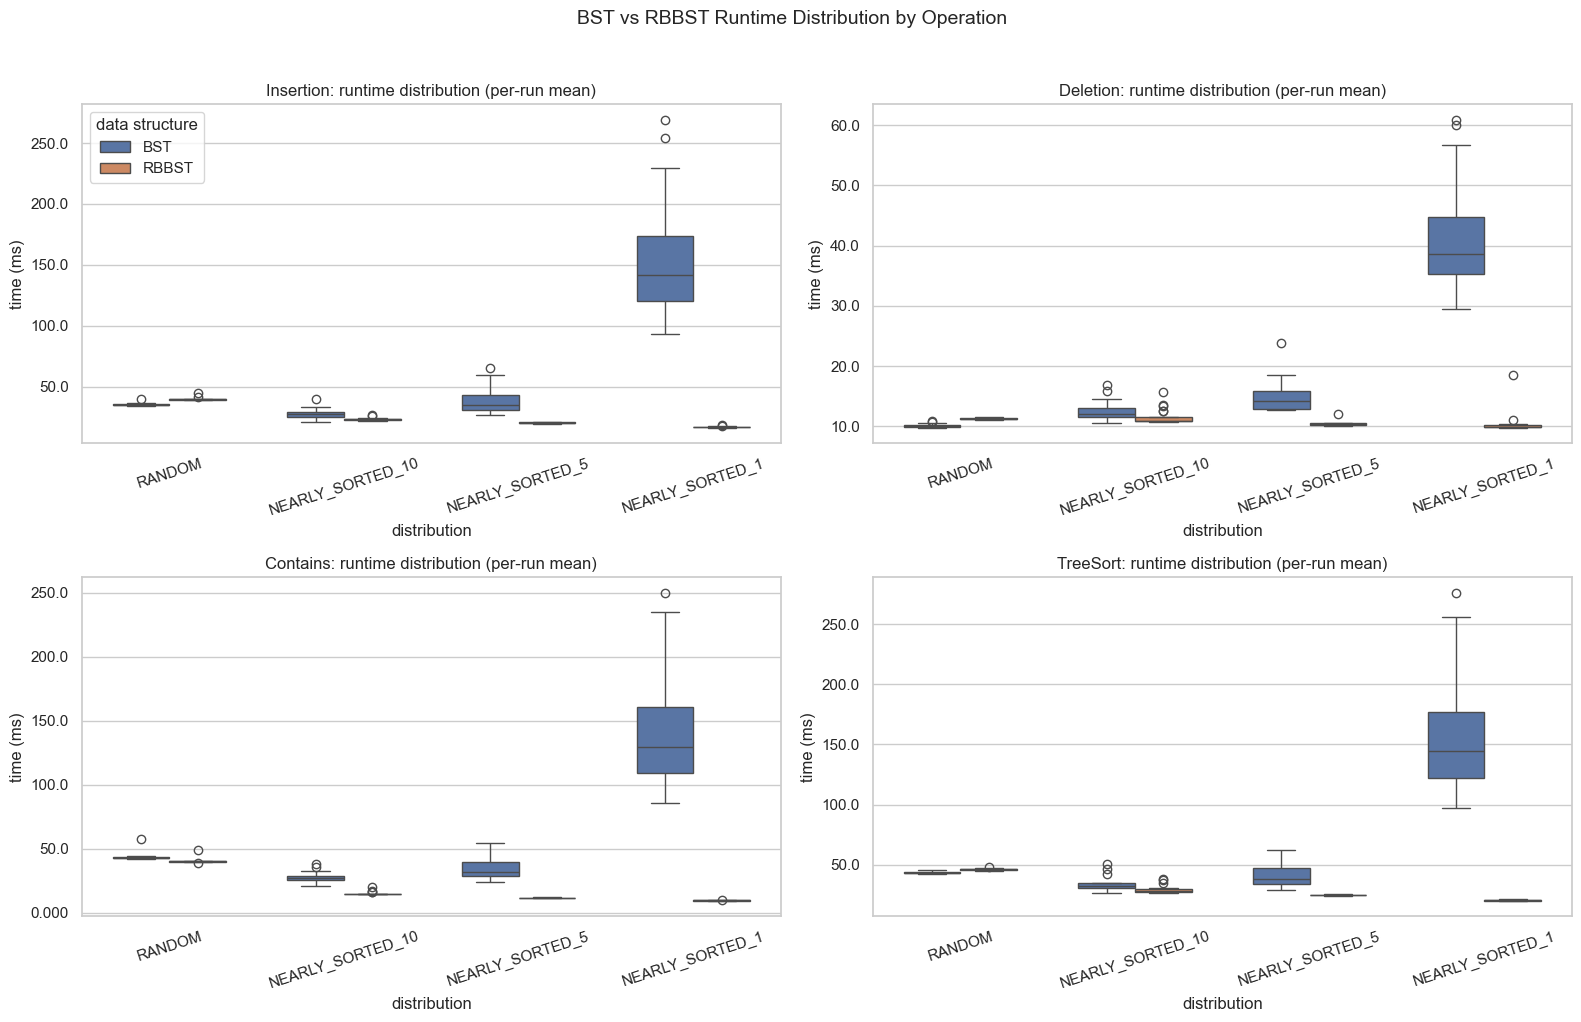

In [35]:
# 1) Distribution of per-run mean runtime by operation and data structure
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=False)

for ax, op in zip(axes.ravel(), OPERATIONS_ORDER):
    sub = df[df["operation"] == op].copy()

    if HAS_SEABORN:
        sns.boxplot(
            data=sub,
            x="distribution",
            y="mean",
            hue="dataStructure",
            order=DISTRIBUTIONS_ORDER,
            hue_order=STRUCTURES_ORDER,
            ax=ax,
            width=0.65,
            showfliers=True
        )
    else:
        for i, dist in enumerate(DISTRIBUTIONS_ORDER):
            for j, ds in enumerate(STRUCTURES_ORDER):
                vals = sub[(sub["distribution"] == dist) & (sub["dataStructure"] == ds)]["mean"].dropna()
                pos = i * 3 + j + 1
                ax.boxplot(vals, positions=[pos], widths=0.6)

        tick_positions = [i * 3 + 1.5 for i in range(len(DISTRIBUTIONS_ORDER))]
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(DISTRIBUTIONS_ORDER, rotation=18)

    ax.set_title(f"{op}: runtime distribution (per-run mean)")
    ax.set_xlabel("distribution")
    ax.set_ylabel("time (ms)")
    ax.tick_params(axis="x", rotation=18)
    ax.yaxis.set_major_formatter(FuncFormatter(fmt_ms_short))

handles, labels = axes[0, 0].get_legend_handles_labels()
if handles:
    axes[0, 0].legend(handles, labels, title="data structure", frameon=True)
for ax in axes.ravel()[1:]:
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

fig.suptitle("BST vs RBBST Runtime Distribution by Operation", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

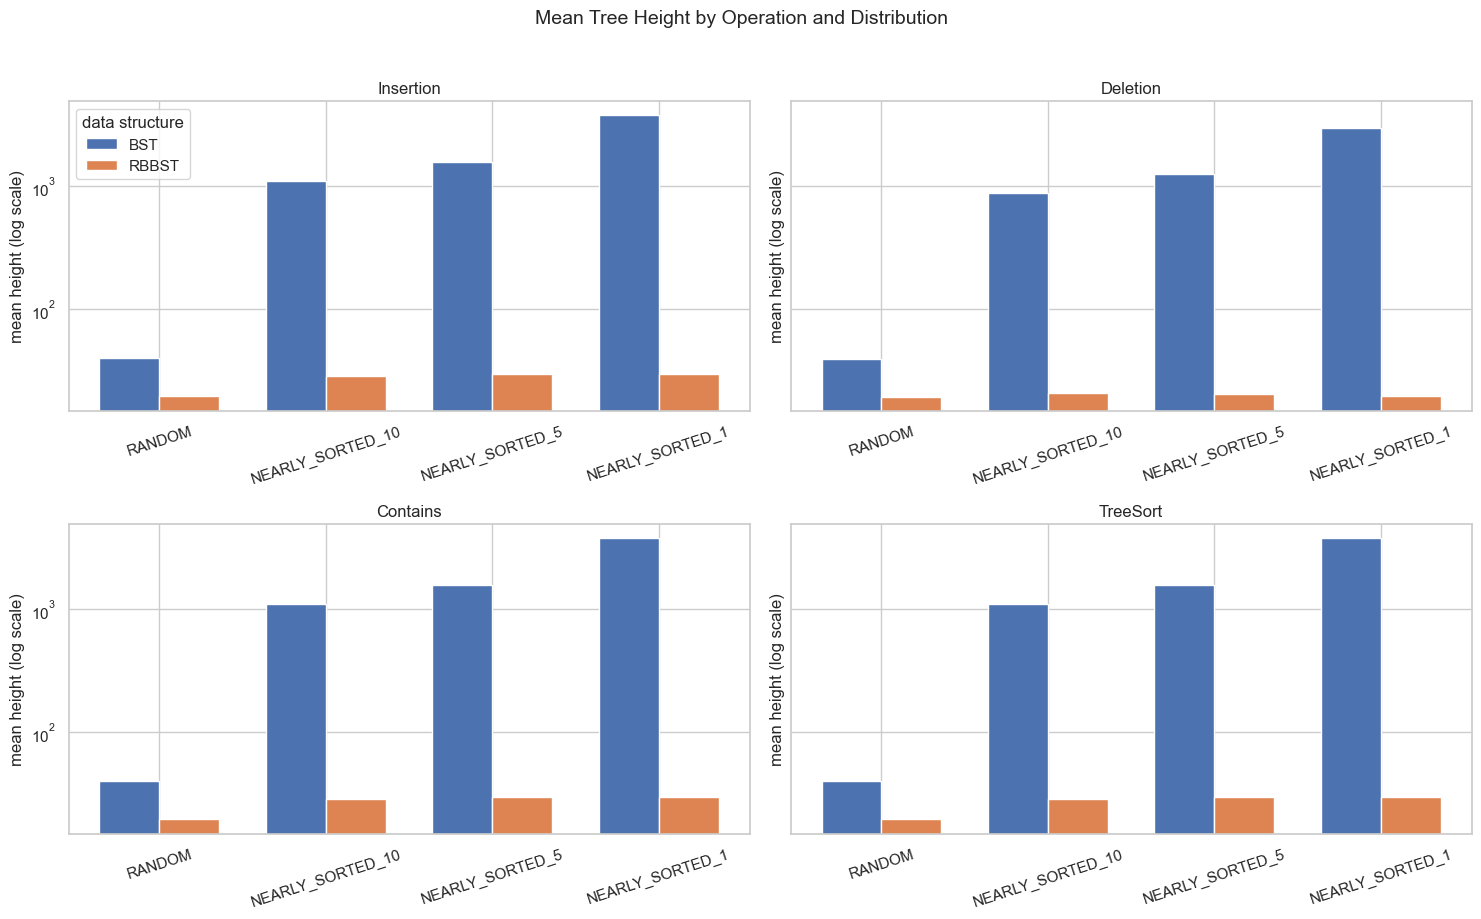

,operation,distribution,height_mean_BST,height_mean_RBBST,height_ratio_bst_over_rbbst,height_diff_BST_minus_RBBST
0,Contains,NEARLY_SORTED_1,3789.00,29.00,130.655172,3760.00
1,Contains,NEARLY_SORTED_10,1097.65,28.00,39.201786,1069.65
2,Contains,NEARLY_SORTED_5,1586.40,29.00,54.703448,1557.40
3,Contains,RANDOM,39.35,19.25,2.044156,20.10
4,Deletion,NEARLY_SORTED_1,3003.00,19.40,154.793814,2983.60
5,Deletion,NEARLY_SORTED_10,882.00,20.45,43.129584,861.55
6,Deletion,NEARLY_SORTED_5,1262.25,20.20,62.487624,1242.05
7,Deletion,RANDOM,38.70,19.05,2.031496,19.65
8,Insertion,NEARLY_SORTED_1,3789.00,29.00,130.655172,3760.00
9,Insertion,NEARLY_SORTED_10,1097.65,28.00,39.201786,1069.65


In [36]:
# 2) Average tree height comparison (BST vs RBBST) as small multiples
height_cmp = cmp.copy()
height_cmp["height_diff_BST_minus_RBBST"] = height_cmp["height_mean_BST"] - height_cmp["height_mean_RBBST"]

fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharey=True)
for ax, op in zip(axes.ravel(), OPERATIONS_ORDER):
    sub = height_cmp[height_cmp["operation"] == op].copy()
    sub = sub.set_index("distribution").reindex(DISTRIBUTIONS_ORDER).reset_index()

    x = np.arange(len(sub))
    width = 0.36
    ax.bar(x - width / 2, sub["height_mean_BST"], width, label="BST")
    ax.bar(x + width / 2, sub["height_mean_RBBST"], width, label="RBBST")

    # Log scale keeps both structures visible despite very large height gaps.
    ax.set_yscale("log")
    ax.set_title(op)
    ax.set_xticks(x)
    ax.set_xticklabels(sub["distribution"], rotation=18)
    ax.set_ylabel("mean height (log scale)")

handles, labels = axes[0, 0].get_legend_handles_labels()
if handles:
    axes[0, 0].legend(handles, labels, title="data structure")

fig.suptitle("Mean Tree Height by Operation and Distribution", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

height_cmp[[
    "operation", "distribution",
    "height_mean_BST", "height_mean_RBBST",
    "height_ratio_bst_over_rbbst", "height_diff_BST_minus_RBBST"
]].sort_values(["operation", "distribution"])

distribution,RANDOM,NEARLY_SORTED_10,NEARLY_SORTED_5,NEARLY_SORTED_1
operation,,,,
Insertion,0.885,1.203,1.874,9.184
Deletion,0.895,1.086,1.426,3.956
Contains,1.078,1.821,2.927,15.007
TreeSort,0.941,1.142,1.623,7.679


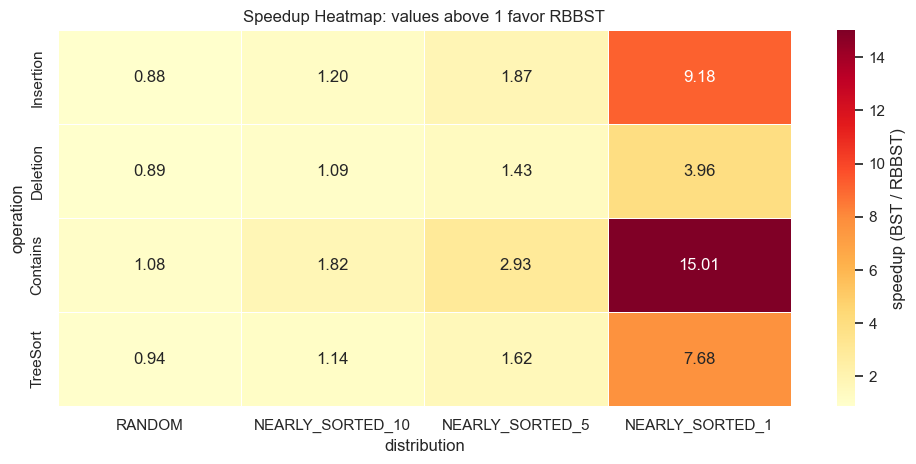

In [37]:
# 3) Speedup heatmap (BST_time / RBBST_time); >1 means RBBST faster
speedup_pivot = (
    cmp.pivot(index="operation", columns="distribution", values="speedup_bst_over_rbbst")
       .reindex(index=OPERATIONS_ORDER, columns=DISTRIBUTIONS_ORDER)
)

display(speedup_pivot.round(3))

fig, ax = plt.subplots(figsize=(10, 4.8))
if HAS_SEABORN:
    sns.heatmap(
        speedup_pivot,
        annot=True,
        fmt=".2f",
        cmap="YlOrRd",
        cbar_kws={"label": "speedup (BST / RBBST)"},
        linewidths=0.5,
        ax=ax
    )
else:
    im = ax.imshow(speedup_pivot.values, aspect="auto")
    for i in range(speedup_pivot.shape[0]):
        for j in range(speedup_pivot.shape[1]):
            ax.text(j, i, f"{speedup_pivot.iloc[i, j]:.2f}", ha="center", va="center", color="black")
    ax.set_xticks(np.arange(len(speedup_pivot.columns)))
    ax.set_xticklabels(speedup_pivot.columns, rotation=20, ha="right")
    ax.set_yticks(np.arange(len(speedup_pivot.index)))
    ax.set_yticklabels(speedup_pivot.index)
    fig.colorbar(im, ax=ax)

ax.set_title("Speedup Heatmap: values above 1 favor RBBST")
ax.set_xlabel("distribution")
ax.set_ylabel("operation")
plt.tight_layout()
plt.show()

## Additional Visualizations

These plots provide a cleaner and more report-friendly comparison view.

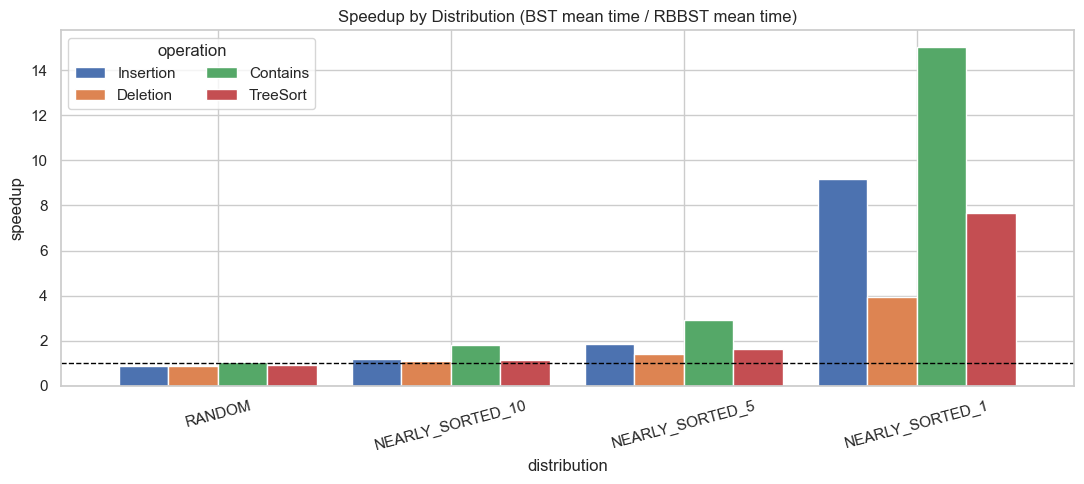

In [38]:
# 4) Grouped bar chart of speedup per operation/distribution
speedup_plot = speedup_pivot.copy().reindex(index=OPERATIONS_ORDER, columns=DISTRIBUTIONS_ORDER)

fig, ax = plt.subplots(figsize=(11, 5))
speedup_plot.T.plot(kind="bar", ax=ax, width=0.85)
ax.axhline(1.0, color="black", linestyle="--", linewidth=1)
ax.set_title("Speedup by Distribution (BST mean time / RBBST mean time)")
ax.set_xlabel("distribution")
ax.set_ylabel("speedup")
ax.legend(title="operation", ncol=2)
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

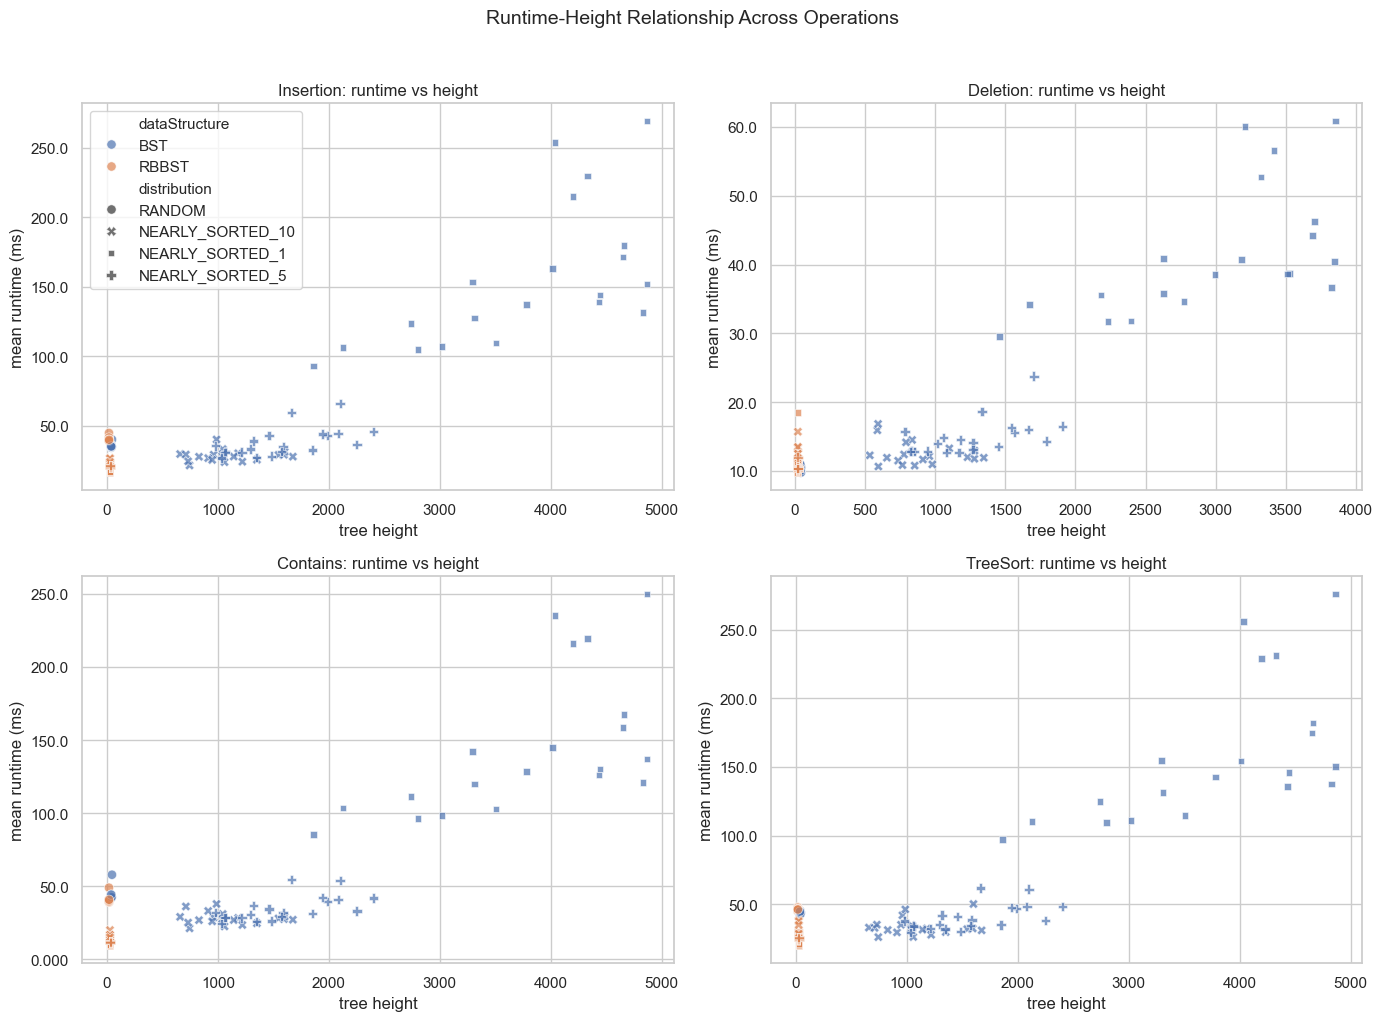

In [39]:
# 5) Relationship between tree height and runtime
scatter_df = df.copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=False, sharey=False)
for ax, op in zip(axes.ravel(), OPERATIONS_ORDER):
    sub = scatter_df[scatter_df["operation"] == op]
    if HAS_SEABORN:
        sns.scatterplot(
            data=sub,
            x="height",
            y="mean",
            hue="dataStructure",
            style="distribution",
            hue_order=STRUCTURES_ORDER,
            ax=ax,
            alpha=0.7,
            s=45
        )
    else:
        for ds in STRUCTURES_ORDER:
            part = sub[sub["dataStructure"] == ds]
            ax.scatter(part["height"], part["mean"], label=ds, alpha=0.7)

    ax.set_title(f"{op}: runtime vs height")
    ax.set_xlabel("tree height")
    ax.set_ylabel("mean runtime (ms)")
    ax.yaxis.set_major_formatter(FuncFormatter(fmt_ms_short))

handles, labels = axes[0, 0].get_legend_handles_labels()
if handles:
    axes[0, 0].legend(handles, labels, frameon=True)
for ax in axes.ravel()[1:]:
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

fig.suptitle("Runtime-Height Relationship Across Operations", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

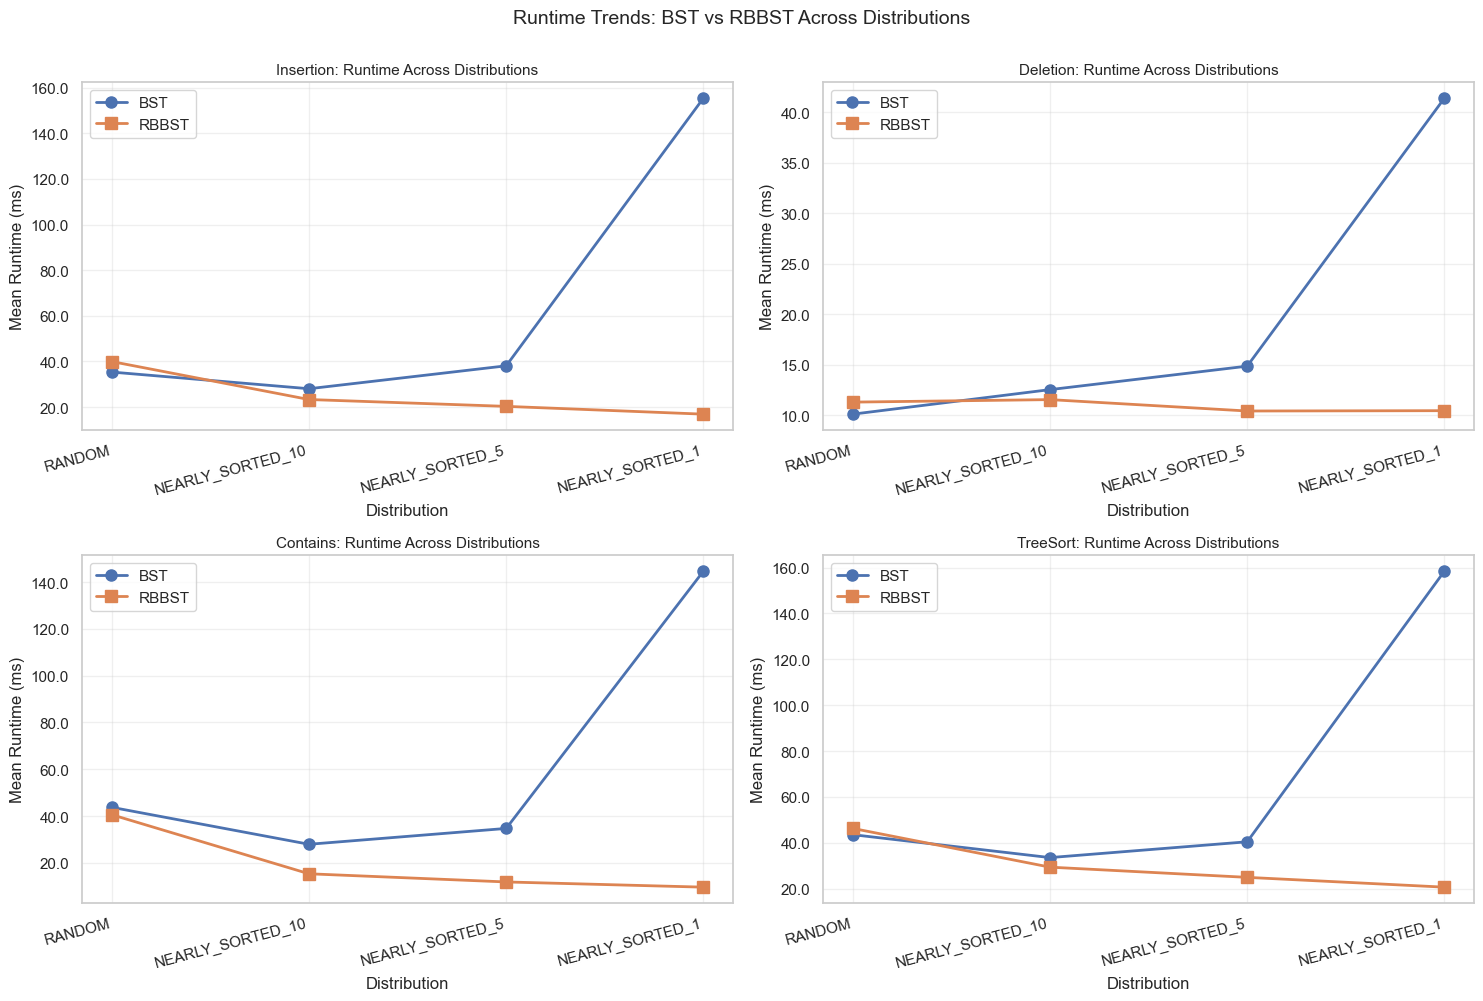

In [46]:
# 6) Line chart: runtime trends across distributions for each operation
line_data = cmp[[
    "operation", "distribution", 
    "mean_mean_BST", "mean_mean_RBBST"
]].copy()

# Map distributions to numeric positions for x-axis
dist_map = {dist: i for i, dist in enumerate(DISTRIBUTIONS_ORDER)}
line_data["dist_x"] = line_data["distribution"].map(dist_map)

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharey=False)
for ax, op in zip(axes.ravel(), OPERATIONS_ORDER):
    sub = line_data[line_data["operation"] == op].sort_values("dist_x")
    
    # Plot lines for each data structure
    ax.plot(sub["dist_x"], sub["mean_mean_BST"], marker="o", label="BST", linewidth=2, markersize=8)
    ax.plot(sub["dist_x"], sub["mean_mean_RBBST"], marker="s", label="RBBST", linewidth=2, markersize=8)
    
    ax.set_title(f"{op}: Runtime Across Distributions", fontsize=11)
    ax.set_xlabel("Distribution")
    ax.set_ylabel("Mean Runtime (ms)")
    ax.set_xticks(range(len(DISTRIBUTIONS_ORDER)))
    ax.set_xticklabels(DISTRIBUTIONS_ORDER, rotation=15, ha="right")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(FuncFormatter(fmt_ms_short))

fig.suptitle("Runtime Trends: BST vs RBBST Across Distributions", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

## Runtime Trends by Distribution

Line chart showing how runtime changes across distributions for each operation.

## Final Summary Table and Observations

## LaTeX Export for Report

The next cell prints LaTeX tables you can paste into your report (Overleaf or any LaTeX editor).

In [40]:
# Build report-ready LaTeX tables (self-contained and jinja2-free)
def latex_escape(text):
    s = str(text)
    replacements = {
        "\\": "\\textbackslash{}",
        "_": "\\_",
        "%": "\\%",
        "&": "\\&",
        "#": "\\#",
        "$": "\\$",
        "{": "\\{",
        "}": "\\}",
    }
    for old, new in replacements.items():
        s = s.replace(old, new)
    return s

def df_to_latex_manual(df_in, caption, label, index=False):
    df_work = df_in.copy()
    if not index:
        df_work = df_work.reset_index(drop=True)
    else:
        df_work = df_work.reset_index()

    headers = [latex_escape(col) for col in df_work.columns]
    align = "l" * len(headers)

    lines = []
    lines.append("\\begin{table}[htbp]")
    lines.append("\\centering")
    lines.append(f"\\caption{{{latex_escape(caption)}}}")
    lines.append(f"\\label{{{latex_escape(label)}}}")
    lines.append(f"\\begin{{tabular}}{{{align}}}")
    lines.append("\\hline")
    lines.append(" & ".join(headers) + " \\\\")
    lines.append("\\hline")

    for _, row in df_work.iterrows():
        vals = [latex_escape(v) for v in row.tolist()]
        lines.append(" & ".join(vals) + " \\\\")

    lines.append("\\hline")
    lines.append("\\end{tabular}")
    lines.append("\\end{table}")
    return "\n".join(lines)

latex_final_table = cmp[[
    "operation", "distribution",
    "mean_mean_BST", "mean_mean_RBBST", "speedup_bst_over_rbbst",
    "median_median_BST", "median_median_RBBST",
    "height_mean_BST", "height_mean_RBBST", "height_ratio_bst_over_rbbst",
    "winner"
]].sort_values(["operation", "distribution"]).copy()

for c in ["mean_mean_BST", "mean_mean_RBBST", "median_median_BST", "median_median_RBBST"]:
    latex_final_table[c] = latex_final_table[c].round(3)
for c in ["speedup_bst_over_rbbst"]:
    latex_final_table[c] = latex_final_table[c].round(3)
for c in ["height_mean_BST", "height_mean_RBBST", "height_ratio_bst_over_rbbst"]:
    latex_final_table[c] = latex_final_table[c].round(2)

latex_by_operation = (
    cmp.groupby("operation", as_index=False)
       .agg(
           avg_speedup=("speedup_bst_over_rbbst", "mean"),
           min_speedup=("speedup_bst_over_rbbst", "min"),
           max_speedup=("speedup_bst_over_rbbst", "max"),
           avg_height_ratio=("height_ratio_bst_over_rbbst", "mean")
       )
       .sort_values("avg_speedup", ascending=False)
       .round({
           "avg_speedup": 3,
           "min_speedup": 3,
           "max_speedup": 3,
           "avg_height_ratio": 2
       })
)

latex_speedup = (
    cmp.pivot(index="operation", columns="distribution", values="speedup_bst_over_rbbst")
       .reindex(index=OPERATIONS_ORDER, columns=DISTRIBUTIONS_ORDER)
       .round(3)
)

latex_final = df_to_latex_manual(
    latex_final_table,
    caption="BST vs RBBST comparison by operation and input distribution (runtime in ms).",
    label="tab:bst_rbbst_comparison",
    index=False
)
latex_op = df_to_latex_manual(
    latex_by_operation,
    caption="Operation-level speedup and height-ratio summary.",
    label="tab:operation_summary",
    index=False
)
latex_speedup_matrix = df_to_latex_manual(
    latex_speedup,
    caption="Speedup matrix (BST mean runtime / RBBST mean runtime).",
    label="tab:speedup_matrix",
    index=True
)

print("=== LATEX TABLE 1: MAIN COMPARISON ===")
print(latex_final)
print("\n=== LATEX TABLE 2: OPERATION SUMMARY ===")
print(latex_op)
print("\n=== LATEX TABLE 3: SPEEDUP MATRIX ===")
print(latex_speedup_matrix)

=== LATEX TABLE 1: MAIN COMPARISON ===
\begin{table}[htbp]
\centering
\caption{BST vs RBBST comparison by operation and input distribution (runtime in ms).}
\label{tab:bst\_rbbst\_comparison}
\begin{tabular}{lllllllllll}
\hline
operation & distribution & mean\_mean\_BST & mean\_mean\_RBBST & speedup\_bst\_over\_rbbst & median\_median\_BST & median\_median\_RBBST & height\_mean\_BST & height\_mean\_RBBST & height\_ratio\_bst\_over\_rbbst & winner \\
\hline
Contains & NEARLY\_SORTED\_1 & 144.663 & 9.64 & 15.007 & 129.579 & 9.697 & 3789.0 & 29.0 & 130.66 & RBBST \\
Contains & NEARLY\_SORTED\_10 & 27.959 & 15.352 & 1.821 & 27.53 & 14.828 & 1097.65 & 28.0 & 39.2 & RBBST \\
Contains & NEARLY\_SORTED\_5 & 34.733 & 11.865 & 2.927 & 32.03 & 11.808 & 1586.4 & 29.0 & 54.7 & RBBST \\
Contains & RANDOM & 43.755 & 40.594 & 1.078 & 43.505 & 40.629 & 39.35 & 19.25 & 2.04 & RBBST \\
Deletion & NEARLY\_SORTED\_1 & 41.422 & 10.47 & 3.956 & 38.665 & 9.907 & 3003.0 & 19.4 & 154.79 & RBBST \\
Deletion & NEA

In [41]:
final_table = cmp[[
    "operation", "distribution",
    "mean_mean_BST", "mean_mean_RBBST", "speedup_bst_over_rbbst",
    "median_median_BST", "median_median_RBBST",
    "height_mean_BST", "height_mean_RBBST", "height_ratio_bst_over_rbbst",
    "winner"
]].sort_values(["operation", "distribution"])

# Avoid Styler dependency (jinja2) for maximum portability.
final_table_display = final_table.copy()
for c in ["mean_mean_BST", "mean_mean_RBBST", "median_median_BST", "median_median_RBBST"]:
    final_table_display[c] = final_table_display[c].round(0).astype("int64")
for c in ["speedup_bst_over_rbbst"]:
    final_table_display[c] = final_table_display[c].round(3)
for c in ["height_mean_BST", "height_mean_RBBST", "height_ratio_bst_over_rbbst"]:
    final_table_display[c] = final_table_display[c].round(2)

display(final_table_display)

by_operation = (
    cmp.groupby("operation", as_index=False)
       .agg(
           avg_speedup=("speedup_bst_over_rbbst", "mean"),
           min_speedup=("speedup_bst_over_rbbst", "min"),
           max_speedup=("speedup_bst_over_rbbst", "max"),
           avg_height_ratio=("height_ratio_bst_over_rbbst", "mean")
       )
       .sort_values("avg_speedup", ascending=False)
)

print("Operation-level summary (higher avg_speedup => larger RBBST advantage):")
display(by_operation.round({
    "avg_speedup": 3,
    "min_speedup": 3,
    "max_speedup": 3,
    "avg_height_ratio": 2
}))

best = by_operation.iloc[0]
worst = by_operation.iloc[-1]
print(
    f"\nStrongest RBBST advantage: {best['operation']} "
    f"(avg speedup {best['avg_speedup']:.3f}x)."
)
print(
    f"Weakest RBBST advantage: {worst['operation']} "
    f"(avg speedup {worst['avg_speedup']:.3f}x)."
)

,operation,distribution,mean_mean_BST,mean_mean_RBBST,speedup_bst_over_rbbst,median_median_BST,median_median_RBBST,height_mean_BST,height_mean_RBBST,height_ratio_bst_over_rbbst,winner
0,Contains,NEARLY_SORTED_1,145,10,15.007,130,10,3789.00,29.00,130.66,RBBST
1,Contains,NEARLY_SORTED_10,28,15,1.821,28,15,1097.65,28.00,39.20,RBBST
2,Contains,NEARLY_SORTED_5,35,12,2.927,32,12,1586.40,29.00,54.70,RBBST
3,Contains,RANDOM,44,41,1.078,44,41,39.35,19.25,2.04,RBBST
4,Deletion,NEARLY_SORTED_1,41,10,3.956,39,10,3003.00,19.40,154.79,RBBST
5,Deletion,NEARLY_SORTED_10,13,12,1.086,12,11,882.00,20.45,43.13,RBBST
6,Deletion,NEARLY_SORTED_5,15,10,1.426,14,10,1262.25,20.20,62.49,RBBST
7,Deletion,RANDOM,10,11,0.895,10,11,38.70,19.05,2.03,BST
8,Insertion,NEARLY_SORTED_1,155,17,9.184,140,16,3789.00,29.00,130.66,RBBST
9,Insertion,NEARLY_SORTED_10,28,23,1.203,28,23,1097.65,28.00,39.20,RBBST


Operation-level summary (higher avg_speedup => larger RBBST advantage):


,operation,avg_speedup,min_speedup,max_speedup,avg_height_ratio
0,Contains,5.208,1.078,15.007,56.65
2,Insertion,3.286,0.885,9.184,56.65
3,TreeSort,2.846,0.941,7.679,56.65
1,Deletion,1.841,0.895,3.956,65.61



Strongest RBBST advantage: Contains (avg speedup 5.208x).
Weakest RBBST advantage: Deletion (avg speedup 1.841x).
